<a href="https://colab.research.google.com/github/Aashish1855/102316104_UCS654_Assignment6_Data-Generation-using-Modelling-and-Simulation-for-ML/blob/main/Data_Generation_using_Modelling_and_Simulation_for_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install simpy

In [3]:
import simpy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor

In [4]:
def queue_simulation(arrival_rate, service_rate, servers):

    env = simpy.Environment()
    server = simpy.Resource(env, capacity=servers)

    waiting_times = []

    def customer(env):
        arrival_time = env.now
        with server.request() as request:
            yield request
            waiting_times.append(env.now - arrival_time)
            service_time = random.expovariate(service_rate)
            yield env.timeout(service_time)

    def arrival_process(env):
        while True:
            yield env.timeout(random.expovariate(arrival_rate))
            env.process(customer(env))

    env.process(arrival_process(env))
    env.run(until=100)

    if len(waiting_times) == 0:
        return 0
    return np.mean(waiting_times)

In [5]:
data = []

for _ in range(1000):
    arrival_rate = random.uniform(1, 10)
    service_rate = random.uniform(1, 8)
    servers = random.randint(1, 5)

    avg_wait = queue_simulation(arrival_rate, service_rate, servers)

    data.append([arrival_rate, service_rate, servers, avg_wait])

df = pd.DataFrame(data, columns=[
    "Arrival_Rate",
    "Service_Rate",
    "Servers",
    "Average_Waiting_Time"
])

df.head()

,Arrival_Rate,Service_Rate,Servers,Average_Waiting_Time
0,6.114279,3.071427,1,21.744490
1,7.609225,1.732390,5,1.557538
2,5.311686,3.761387,5,0.000304
3,2.683487,1.791301,5,0.000352
4,7.167318,7.833888,3,0.005258


In [6]:
X = df[["Arrival_Rate", "Service_Rate", "Servers"]]
y = df["Average_Waiting_Time"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "KNN": KNeighborsRegressor(),
    "SVR": SVR(),
    "Gradient Boosting": GradientBoostingRegressor(),
    "MLP": MLPRegressor(max_iter=500)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    results.append([name, mae, rmse, r2])

results_df = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R2"])
results_df.sort_values(by="R2", ascending=False)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


,Model,MAE,RMSE,R2
3,KNN,0.891595,2.269491,0.946150
2,Random Forest,1.006668,2.277642,0.945762
1,Decision Tree,0.935758,2.396375,0.939960
6,MLP,1.349241,2.422146,0.938662
5,Gradient Boosting,1.437654,2.743571,0.921302
4,SVR,2.229778,4.326673,0.804277
0,Linear Regression,5.155003,6.749389,0.523721


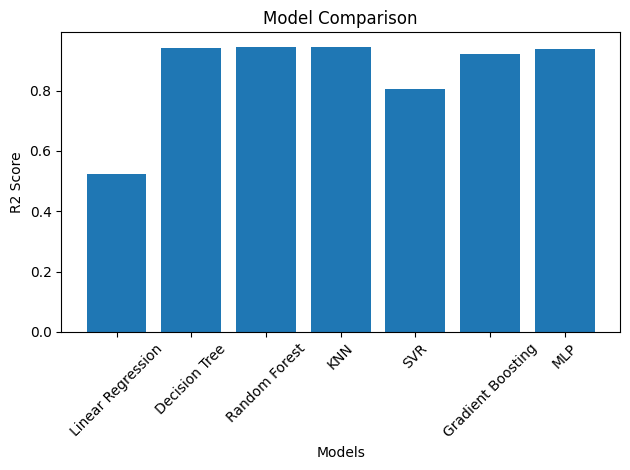

In [8]:
plt.figure()
plt.bar(results_df["Model"], results_df["R2"])
plt.xticks(rotation=45)
plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.title("Model Comparison")
plt.tight_layout()
plt.show()